In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_style("whitegrid")
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style="whitegrid", palette="pastel")


import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# import data 

In [2]:
df = pd.read_csv(r"C:\Users\ssury\Downloads\steam_top_games_2026.csv")

----

## check and remove missing values and also remove USELESS colums

In [3]:
missing_percent = df.isnull().mean() * 100
df = df.dropna()
df.drop(columns= ["app_id","coming_soon","short_description","header_image"],inplace= True)
df = df[~df["name"].str.contains("Removed", case=False, na=False)]

---

## Rename colums name for better understanding 

In [4]:
rename_dict = {
    # Core identity
    'name': 'game_name',
    'release_date': 'release_date',

    # Pricing
    'price_usd': 'price_usd',
    'is_free': 'is_free_to_play',
    'discount_pct': 'discount_percentage',

    # Company info
    'developer': 'developer_name',
    'publisher': 'publisher_name',

    # Content metadata
    'genres': 'game_genres',
    'categories': 'game_categories',
    'tags': 'game_tags',

    # Platform availability
    'platforms_win': 'is_windows_supported',
    'platforms_mac': 'is_mac_supported',
    'platforms_linux': 'is_linux_supported',

    # Quality / reputation
    'metacritic_score': 'critic_score_metacritic',
    'recommendations': 'total_recommendations',

    # Reviews
    'positive_reviews': 'positive_reviews',
    'negative_reviews': 'negative_reviews',

    # Ownership (range-based)
    'estimated_owners': 'estimated_owners',

    # Engagement (minutes)
    'avg_playtime_forever': 'avg_playtime_forever',
    'avg_playtime_2weeks': 'avg_playtime_2weeks',
    'median_playtime': 'median_playtime',

    # Popularity
    'peak_ccu': 'peak_concurrent_users',

    # Compliance / monetization
    'required_age': 'required_age',
    'dlc_count': 'dlc_total_count',
    'achievements': 'total_achievements'
}

In [5]:
df.rename(columns=rename_dict, inplace=True)

## Trasform estimated_owners colums into owners_avg

In [6]:
estimated_owner = df["estimated_owners"].str.split(" .. ")


df['owners_avg'] = estimated_owner.apply(
    lambda x: (int(x[0].replace(',', '')) + int(x[1].replace(',', ''))) / 2)


df.drop(columns="estimated_owners", inplace= True)

---

## Create new colums

In [7]:
df["review_score"] = df["positive_reviews"] / (df["positive_reviews"] + df["negative_reviews"])

df['total_reviews'] = df['positive_reviews'] + df['negative_reviews']

df['estimated_revenue'] = df['owners_avg'] * df['price_usd']
df['estimated_revenue'] = df['estimated_revenue'].astype(int)
df['avg_playtime_hours'] = df['avg_playtime_forever'] / 60
df['avg_playtime_hours'] = df['avg_playtime_hours'].round(2)

df['release_year'] = pd.to_datetime(df['release_date']).dt.year
df['release_month'] = pd.to_datetime(df['release_date']).dt.month



df["retention_ratio"] = df["avg_playtime_2weeks"] / df["avg_playtime_forever"]

# Handle division issues
df["retention_ratio"] = df["retention_ratio"].replace([np.inf, -np.inf], np.nan)

# Cap logically (IMPORTANT)
df["retention_ratio"] = df["retention_ratio"].clip(0, 1)

---

## convert all Bools value into Int and trasform date into YYYY-MM-DD

In [8]:
df['is_windows_supported'] = df['is_windows_supported'].astype(int)
df['is_mac_supported'] = df['is_mac_supported'].astype(int)
df['is_linux_supported'] = df['is_linux_supported'].astype(int)
df['is_free_to_play'] = df['is_free_to_play'].astype(int)
df['owners_avg'] = df['owners_avg'].astype(int)
df['critic_score_metacritic'] = df['critic_score_metacritic'].astype(int)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

---

In [9]:
df['game_categories'] = df['game_categories'].str.replace(r"[\[\]']", "", regex=True)

---

## Create PIPELINE

In [10]:
# -----------------------------
# 1. CLEAN GENRES COLUMN
# -----------------------------
df["game_genres"] = (
    df["game_genres"]
    .fillna("")
    .astype(str)
    .str.replace(r"[\[\]']", "", regex=True)
    .apply(lambda x: x.split(",") if x != "" else [])
)

# -----------------------------
# 2. CLEAN TAGS COLUMN (ROBUST)
# -----------------------------
df["game_tags"] = (
    df["game_tags"]
    .fillna("")
    .astype(str)
    .str.replace(r"[\[\]']", "", regex=True)
)

# Ensure always list
df["game_tags"] = df["game_tags"].apply(
    lambda x: x.split(",") if x != "" else []
)

# -----------------------------
# 3. EXPLODE
# -----------------------------
df_genre = df.explode("game_genres")
df_tags = df.explode("game_tags")

# -----------------------------
# 4. CLEAN VALUES
# -----------------------------
df_genre["game_genres"] = df_genre["game_genres"].str.strip()
df_tags["game_tags"] = df_tags["game_tags"].str.strip()

# Remove invalid values
df_genre = df_genre[
    (df_genre["game_genres"] != "") &
    (df_genre["game_genres"].notna())
]

df_tags = df_tags[
    (df_tags["game_tags"] != "") &
    (df_tags["game_tags"].notna())
]

# -----------------------------
# 5. VALIDATION (IMPORTANT)
# -----------------------------
print("Unique Tags:", df_tags["game_tags"].nunique())
print(df_tags["game_tags"].value_counts().head())

# -----------------------------
# 6. TOP TAG PERFORMANCE
# -----------------------------
top_tag_perf = (
    df_tags.groupby("game_tags")["owners_avg"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)

Unique Tags: 334
game_tags
Singleplayer    302
Action          261
Adventure       204
Multiplayer     175
Indie           150
Name: count, dtype: int64


## covert and analysis  categories and tags

In [11]:
df["game_categories"] = df["game_categories"].str.split(", ")
df["game_tags"] = df["game_tags"].str.split(", ")

In [12]:
df_cat = df.explode("game_categories")
df_tags = df.explode("game_tags")

In [13]:
df.describe()

,release_date,price_usd,is_free_to_play,discount_percentage,is_windows_supported,is_mac_supported,is_linux_supported,critic_score_metacritic,total_recommendations,positive_reviews,negative_reviews,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_concurrent_users,required_age,dlc_total_count,total_achievements,owners_avg,review_score,total_reviews,estimated_revenue,avg_playtime_hours,release_year,release_month,retention_ratio
count,525,525.000000,525.000000,525.000000,525.0,525.000000,525.000000,525.000000,5.250000e+02,5.250000e+02,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,5.250000e+02,525.000000,5.250000e+02,5.250000e+02,525.000000,525.000000,525.000000,523.000000
mean,2016-03-19 00:57:36,16.274800,0.041905,12.815238,1.0,0.398095,0.295238,76.952381,2.628067e+04,2.974653e+04,3494.293333,1304.249524,89.466667,448.710476,1092.150476,3.579048,3.822857,43.409524,1.967143e+06,0.839182,3.324082e+04,3.699510e+07,21.737524,2015.697143,6.697143,0.058149
min,2004-11-01 00:00:00,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,24.000000,0.000000e+00,1.880000e+02,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000e+05,0.242016,3.440000e+02,0.000000e+00,0.000000,2004.000000,1.000000,0.000000
25%,2013-03-21 00:00:00,5.990000,0.000000,0.000000,1.0,0.000000,0.000000,72.000000,2.500000e+03,2.872000e+03,485.000000,270.000000,0.000000,142.000000,7.000000,0.000000,0.000000,13.000000,3.500000e+05,0.784747,3.591000e+03,3.496500e+06,4.500000,2013.000000,4.000000,0.000000
50%,2016-06-07 00:00:00,14.990000,0.000000,0.000000,1.0,0.000000,0.000000,78.000000,6.597000e+03,7.194000e+03,1101.000000,529.000000,0.000000,248.000000,36.000000,0.000000,1.000000,35.000000,7.500000e+05,0.874826,8.619000e+03,8.746500e+06,8.820000,2016.000000,7.000000,0.000000
75%,2019-05-29 00:00:00,19.990000,0.000000,0.000000,1.0,1.000000,1.000000,83.000000,1.824800e+04,2.048400e+04,2797.000000,1321.000000,19.000000,467.000000,193.000000,0.000000,3.000000,54.000000,1.500000e+06,0.926774,2.313600e+04,2.998500e+07,22.020000,2019.000000,9.000000,0.013215
max,2025-11-07 00:00:00,69.990000,1.000000,94.000000,1.0,1.000000,1.000000,96.000000,1.126145e+06,1.071135e+06,156649.000000,27310.000000,4204.000000,14325.000000,143870.000000,18.000000,200.000000,709.000000,3.500000e+07,0.984714,1.227784e+06,2.099650e+09,455.170000,2025.000000,12.000000,1.000000
std,NaN,13.428896,0.200563,28.367311,0.0,0.489972,0.456585,9.366765,7.675450e+04,8.274639e+04,10479.945331,2525.239440,304.113066,823.970910,7333.004691,6.894789,12.199403,54.484169,4.019317e+06,0.119047,9.168083e+04,1.284014e+08,42.087275,4.454787,3.324339,0.161274


In [14]:
df[['owners_avg', 'avg_playtime_forever', 'peak_concurrent_users']].describe()

,owners_avg,avg_playtime_forever,peak_concurrent_users
count,5.250000e+02,525.000000,525.000000
mean,1.967143e+06,1304.249524,1092.150476
std,4.019317e+06,2525.239440,7333.004691
min,3.500000e+05,0.000000,0.000000
25%,3.500000e+05,270.000000,7.000000
50%,7.500000e+05,529.000000,36.000000
75%,1.500000e+06,1321.000000,193.000000
max,3.500000e+07,27310.000000,143870.000000


In [15]:
df[['owners_avg', 'review_score', 'price_usd', 'peak_concurrent_users']].corr()

,owners_avg,review_score,price_usd,peak_concurrent_users
owners_avg,1.000000,0.146807,0.092446,0.640921
review_score,0.146807,1.000000,0.105621,0.058907
price_usd,0.092446,0.105621,1.000000,0.178988
peak_concurrent_users,0.640921,0.058907,0.178988,1.000000


In [16]:
df.groupby('is_free_to_play')[['owners_avg', 'estimated_revenue']].mean()

,owners_avg,estimated_revenue
is_free_to_play,,
0,1.820080e+06,3.861318e+07
1,5.329545e+06,0.000000e+00


In [17]:
df[['avg_playtime_hours', 'owners_avg']].corr()

,avg_playtime_hours,owners_avg
avg_playtime_hours,1.000000,0.575029
owners_avg,0.575029,1.000000


In [18]:
df[['review_score', 'owners_avg']].corr()

,review_score,owners_avg
review_score,1.000000,0.146807
owners_avg,0.146807,1.000000


In [19]:
df["owners_avg"].value_counts()

owners_avg
350000      180
750000      143
1500000      99
3500000      64
7500000      26
15000000      8
35000000      5
Name: count, dtype: int64

----

----

----

## 📊 Key Performance Indicators (KPIs)

- Ownership (Millions) → Market success
- Avg Playtime (Hours) → Player engagement
- Retention Ratio → Player stickiness
- Revenue → Financial performance
- Review Score → Player satisfaction

# ---------------lets Make Chats---------------

In [20]:
# Remove extreme outliers (top 5%)
upper_limit = df["owners_avg"].quantile(0.95)
df_clean = df[df["owners_avg"] <= upper_limit]

df["owners_millions"] = df["owners_avg"] / 1e6
df["playtime_hours"] = df["avg_playtime_forever"] / 60

----

<Axes: xlabel='playtime_hours', ylabel='owners_millions'>

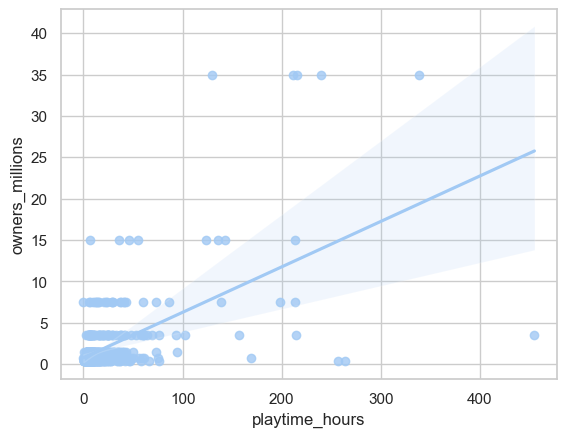

In [21]:
sns.regplot(x="playtime_hours", y="owners_millions", data=df)

----

Text(0.5, 1.0, 'Feature Correlation Heatmap')

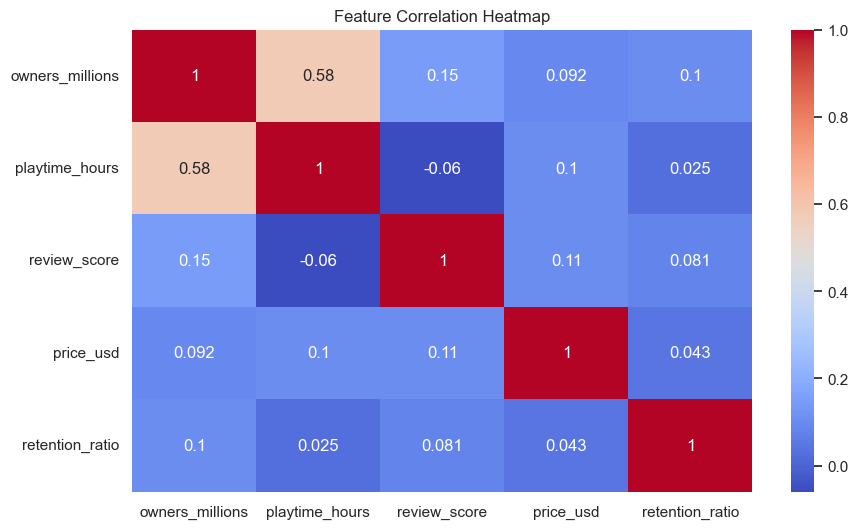

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df[[
    "owners_millions",
    "playtime_hours",
    "review_score",
    "price_usd",
    "retention_ratio"
]].corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

## 📊 Insight:
Player engagement (playtime) shows the strongest positive correlation with ownership, while price and review score have weaker relationships.

### 💼 Business Interpretation:
User engagement is a more reliable indicator of success compared to pricing or review ratings.

### Strategic Insight:
Focusing on gameplay experience and retention mechanics is more impactful than competing on price alone.

----

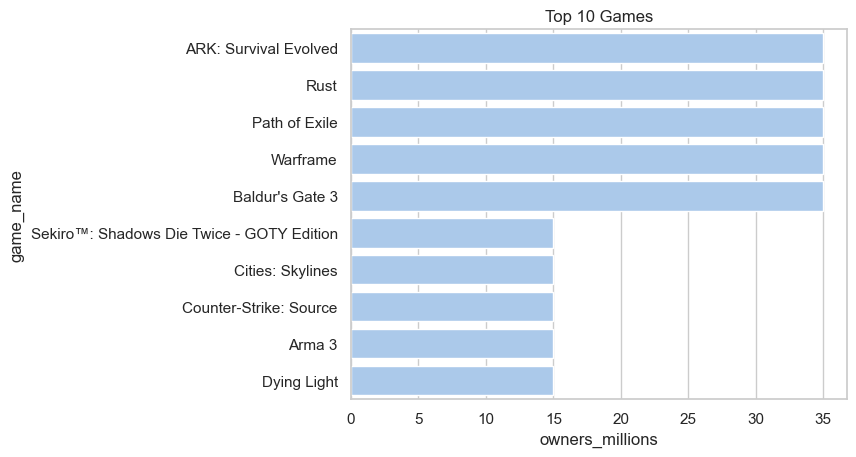

In [23]:
top_games = df.sort_values("owners_avg", ascending=False).head(10)

sns.barplot(
    x=top_games["owners_millions"],
    y=top_games["game_name"]
)
plt.title("Top 10 Games")
plt.show()

-----

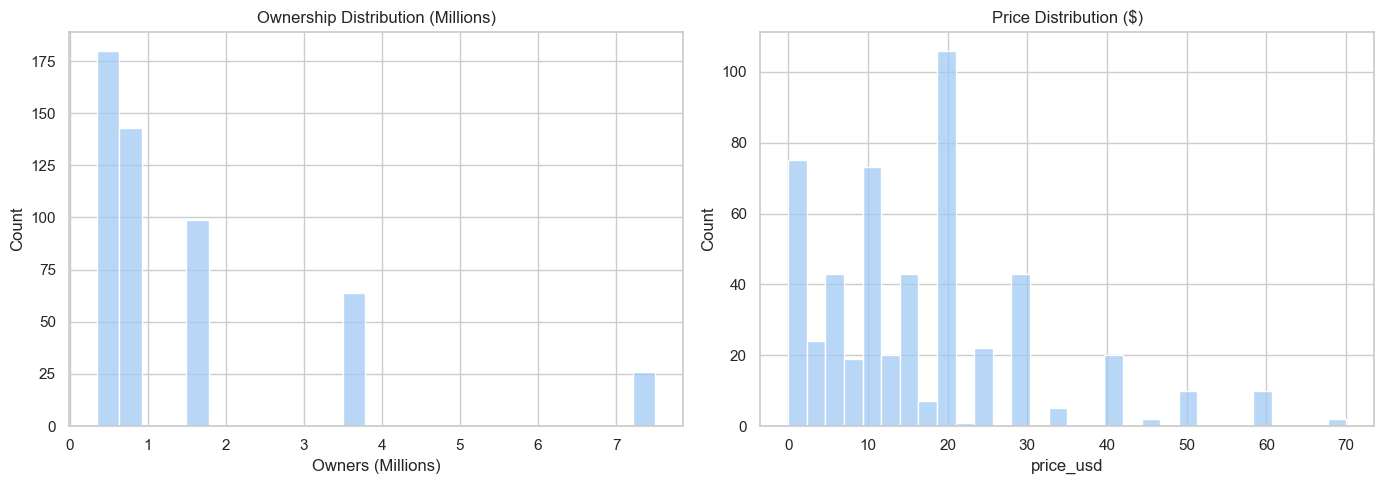

In [24]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df_clean["owners_avg"]/1e6, bins=25, ax=axes[0])
axes[0].set_title("Ownership Distribution (Millions)")
axes[0].set_xlabel("Owners (Millions)")

sns.histplot(df["price_usd"], bins=30, ax=axes[1])
axes[1].set_title("Price Distribution ($)")

plt.tight_layout()
plt.show()

## 1. Ownership Distribution (Millions)
### 📊 Insight

The distribution of game ownership is highly skewed, with a small number of games capturing a disproportionately large player base while most games remain below 1 million owners.

### 💼 Business Interpretation

This reflects a winner-takes-all market, where only a few titles achieve breakout success, making discoverability, differentiation, and strong positioning critical for new games.

## 2. Price Distribution ($)
### 📊 Insight

Most games are priced within the $5–$20 range, with relatively few premium-priced titles above $40.

## 💼 Business Interpretation

Developers tend to adopt competitive mid-range pricing strategies to maximize accessibility, indicating strong price sensitivity among players.

---

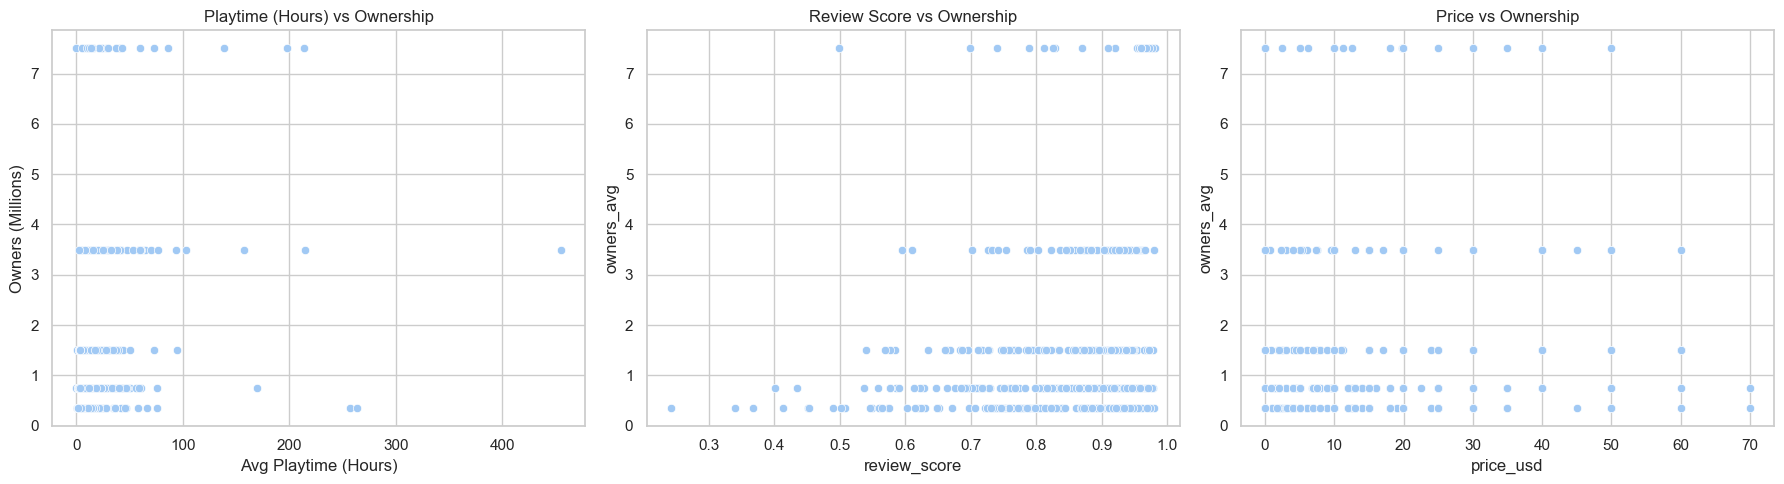

In [25]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.scatterplot(x=df_clean["avg_playtime_forever"]/60,
                y=df_clean["owners_avg"]/1e6,
                ax=axes[0])
axes[0].set_title("Playtime (Hours) vs Ownership")
axes[0].set_xlabel("Avg Playtime (Hours)")
axes[0].set_ylabel("Owners (Millions)")

sns.scatterplot(x="review_score",
                y=df_clean["owners_avg"]/1e6,
                data=df_clean,
                ax=axes[1])
axes[1].set_title("Review Score vs Ownership")

sns.scatterplot(x="price_usd",
                y=df_clean["owners_avg"]/1e6,
                data=df_clean,
                ax=axes[2])
axes[2].set_title("Price vs Ownership")

plt.tight_layout()
plt.show()

## 3. Playtime (Hours) vs Ownership
### 📊 Insight

Games with higher average playtime tend to achieve higher ownership, showing a clear positive relationship between engagement and scale.

### 💼 Business Interpretation

Player engagement is a primary growth driver, suggesting that games which retain users longer are more likely to expand their player base organically.

## 4. Review Score vs Ownership
### 📊 Insight

Higher review scores show only a weak and inconsistent relationship with ownership levels.

### 💼 Business Interpretation

While reviews influence perception, they are not the main success driver—gameplay experience and engagement have a stronger impact.

## 5. Price vs Ownership
### 📊 Insight

Ownership varies significantly across all price levels, with no strong correlation between price and game success.

## 💼 Business Interpretation

Pricing alone does not determine success; instead, value delivery and engagement matter more than price positioning.

---

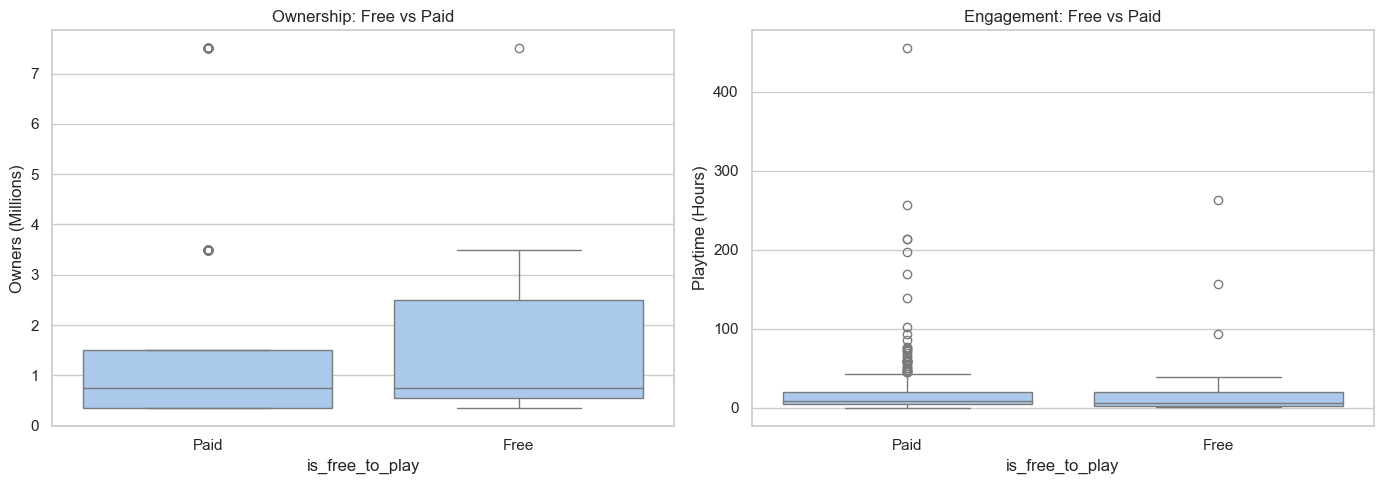

In [26]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(x="is_free_to_play",
            y=df_clean["owners_avg"]/1e6,
            data=df_clean,
            ax=axes[0])

axes[0].set_title("Ownership: Free vs Paid")
axes[0].set_xticklabels(["Paid","Free"])
axes[0].set_ylabel("Owners (Millions)")

sns.boxplot(x="is_free_to_play",
            y=df_clean["avg_playtime_forever"]/60,
            data=df_clean,
            ax=axes[1])

axes[1].set_title("Engagement: Free vs Paid")
axes[1].set_xticklabels(["Paid","Free"])
axes[1].set_ylabel("Playtime (Hours)")

plt.tight_layout()
plt.show()

## 6. Ownership: Free vs Paid
### 📊 Insight

Free-to-play games generally achieve higher ownership compared to paid games.

### 💼 Business Interpretation

Free-to-play models are effective for user acquisition and scaling reach, lowering entry barriers for players.

## 7. Engagement: Free vs Paid
### 📊 Insight

Both free and paid games show wide variation in playtime, with no clear dominance in engagement levels.

### 💼 Business Interpretation

Monetization strategy does not guarantee engagement—game design, mechanics, and content depth are more critical.

---

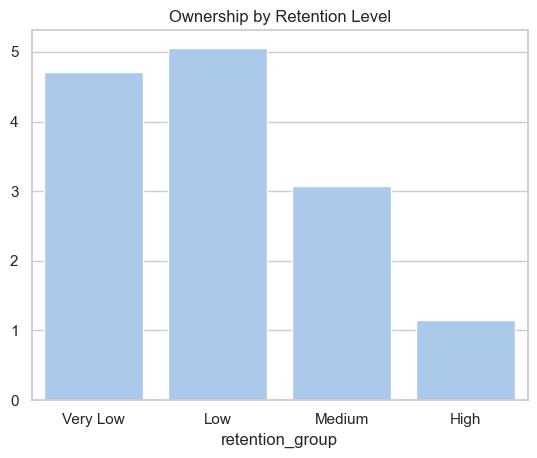

In [43]:
df["retention_group"] = pd.cut(
    df["retention_ratio"],
    bins=[0, 0.1, 0.3, 0.6, 1],
    labels=["Very Low", "Low", "Medium", "High"]
)

retention_perf = df.groupby("retention_group")["owners_millions"].mean()


sns.barplot(x=retention_perf.index, y=retention_perf.values)
plt.title("Ownership by Retention Level")
plt.show()

## 8. Retention vs Ownership
### 📊 Insight

Ownership increases with higher retention levels, with games in the "Medium" and "High" retention groups showing significantly higher average ownership.

### 💼 Business Interpretation:
Players who continue engaging with a game contribute to sustained growth and higher adoption, making retention a critical performance driver.

### Strategic Insight:
Improving early player retention can directly impact long-term success, making onboarding experience and gameplay loop design crucial.

---

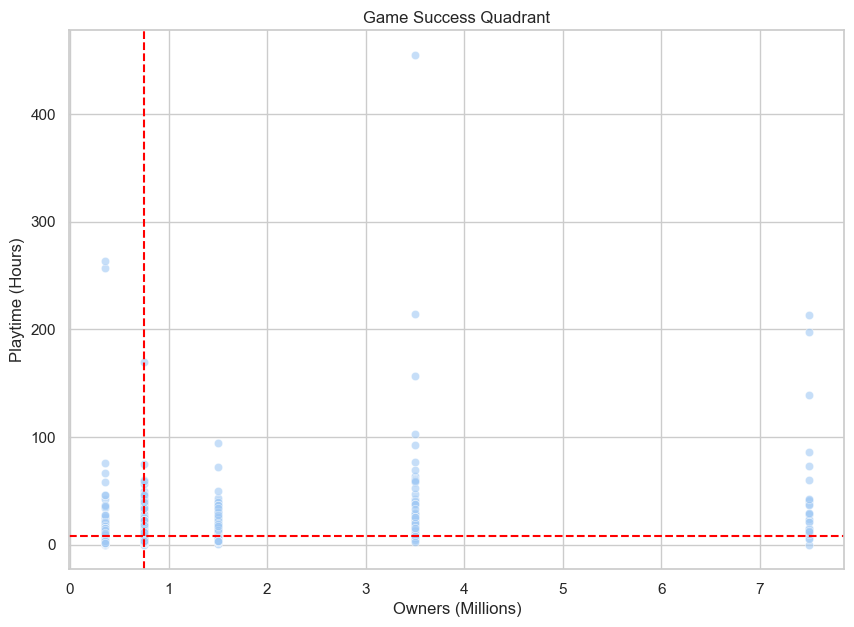

In [28]:
x_median = df_clean["owners_avg"].median()
y_median = df_clean["avg_playtime_forever"].median()

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df_clean["owners_avg"]/1e6,
    y=df_clean["avg_playtime_forever"]/60,
    alpha=0.6
)

plt.axvline(x=x_median/1e6, color='red', linestyle='--')
plt.axhline(y=y_median/60, color='red', linestyle='--')

plt.title("Game Success Quadrant")
plt.xlabel("Owners (Millions)")
plt.ylabel("Playtime (Hours)")

plt.show()

## 9. Game Success Quadrant
### 📊 Insight

Games in the top-right quadrant (high ownership and high playtime) represent the most successful titles in the dataset.

### 💼 Business Interpretation

True success is driven by a combination of strong user acquisition and sustained engagement.

### ⚠️ Edge Case

High ownership + low playtime → short-term popularity
Low ownership + high playtime → niche but loyal audience

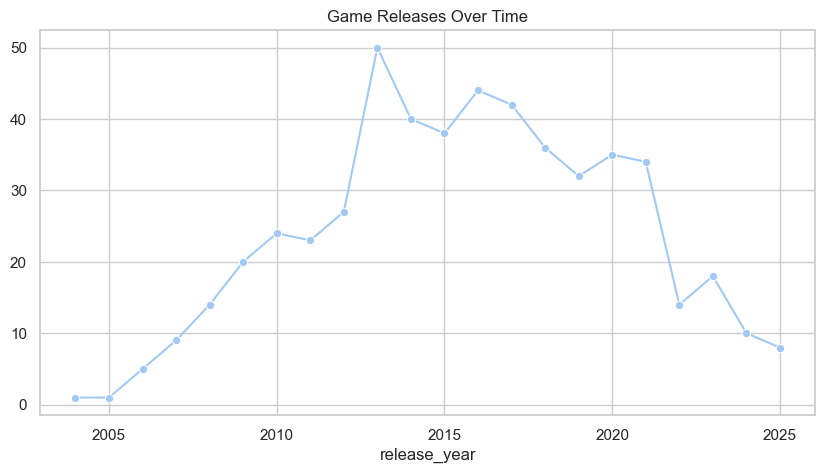

In [29]:
year_data = df.groupby('release_year').size()

plt.figure(figsize=(10,5))
sns.lineplot(x=year_data.index, y=year_data.values, marker='o')

plt.title("Game Releases Over Time")
plt.show()

## 10. Game Releases Over Time
### 📊 Insight
The number of games released has increased over time, reflecting steady growth in the gaming industry.

### 💼 Business Interpretation
The market is becoming more competitive, making it increasingly difficult for new games to stand out without strong differentiation.

---

In [40]:
df["is_free_to_play"]

4       0
5       0
11      0
13      0
15      0
24      0
25      0
33      0
35      0
36      0
39      0
41      0
55      0
56      0
58      0
61      0
62      0
63      0
68      0
73      0
74      0
81      0
82      0
83      0
84      0
88      0
89      0
90      0
92      0
93      0
95      0
96      0
101     1
102     0
107     0
108     0
113     0
116     0
121     0
128     0
133     0
134     0
135     0
140     0
142     0
144     0
145     0
146     0
148     0
149     0
150     0
152     0
154     0
155     0
158     0
161     0
171     0
173     0
174     0
176     0
177     0
183     0
184     0
193     0
194     0
196     0
197     0
198     0
199     0
200     0
203     0
204     0
207     0
208     0
210     0
212     0
214     0
215     0
216     1
219     0
225     0
227     0
228     0
232     0
243     0
244     0
245     0
246     0
247     0
250     0
251     0
260     0
261     0
263     0
266     0
267     0
268     0
270     0
271     0
273     0


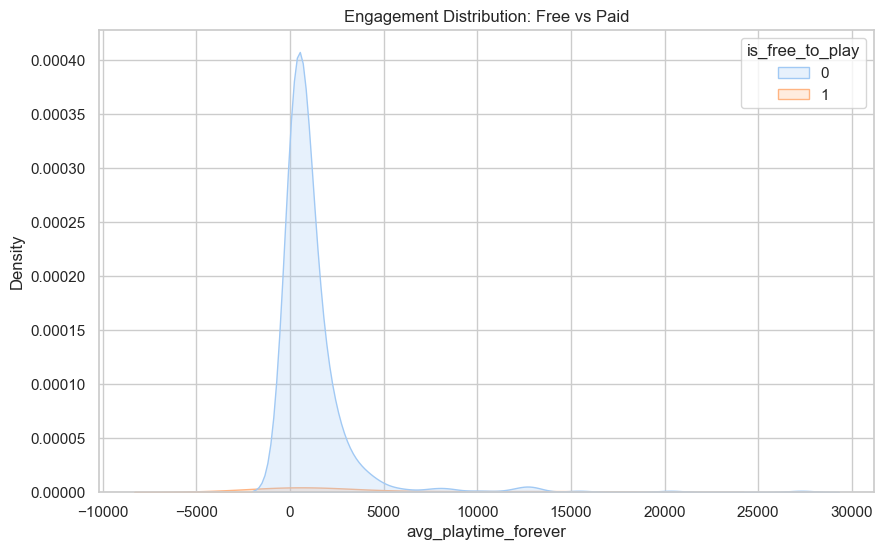

In [46]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='avg_playtime_forever',
    hue='is_free_to_play',
    fill=True
)

plt.title("Engagement Distribution: Free vs Paid")
plt.show()

## 11. Engagement Distribution (Free vs Paid - KDE)

### 📊 Insight
Free-to-play games show a broader engagement distribution, while paid games are more concentrated.

### 💼 Business Interpretation
Free games attract diverse user behavior, whereas paid games tend to target a more specific and committed audience segment.

---

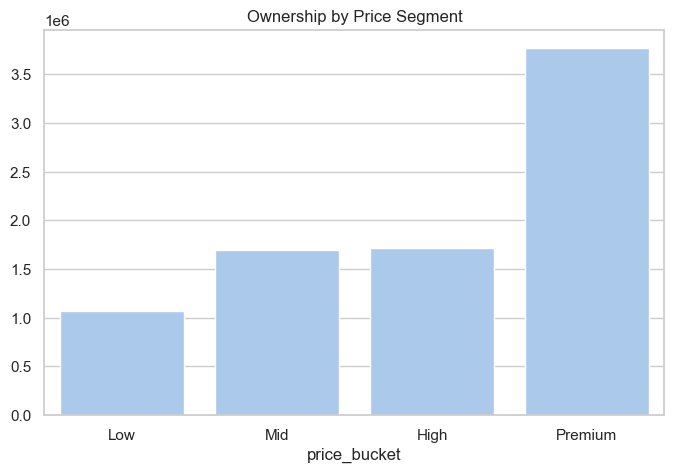

In [31]:
df['price_bucket'] = pd.cut(
    df['price_usd'],
    bins=[0,5,15,30,60],
    labels=['Low','Mid','High','Premium']
)

price_perf = df.groupby('price_bucket')['owners_avg'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=price_perf.index, y=price_perf.values)

plt.title("Ownership by Price Segment")
plt.show()

## 12. Ownership by Price Segment

### 📊 Insight
Lower-priced and mid-priced games tend to achieve higher ownership compared to premium-priced games.

### 💼 Business Interpretation
Players demonstrate price sensitivity, but strong-performing premium games indicate that value perception can override pricing barriers.

---

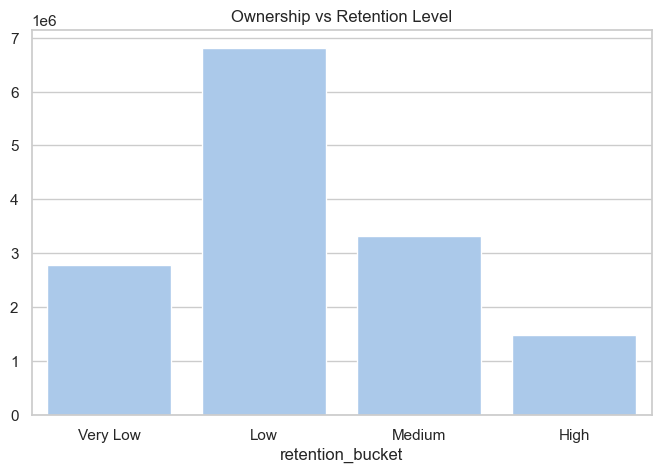

In [32]:
df['retention_bucket'] = pd.cut(
    df['retention_ratio'],
    bins=[0,0.05,0.2,0.5,1],
    labels=['Very Low','Low','Medium','High']
)

retention_perf = df.groupby('retention_bucket')['owners_avg'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=retention_perf.index, y=retention_perf.values)

plt.title("Ownership vs Retention Level")
plt.show()

## 13. Ownership vs Retention Level

### 📊 Insight
Ownership generally increases with higher retention levels, although some mid-retention games also perform strongly.

### 💼 Business Interpretation
Retention is a key success factor, but initial acquisition strategies can still drive ownership even with moderate retention.

---

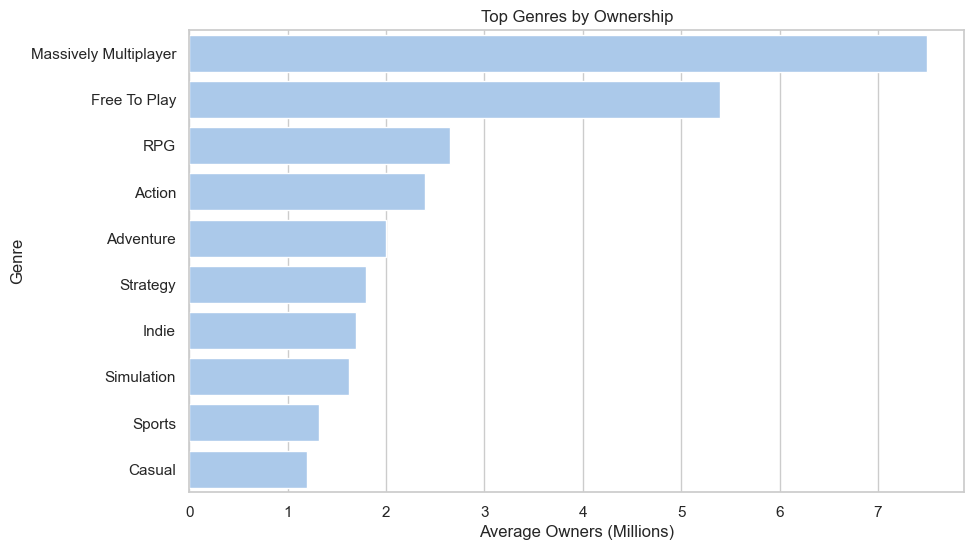

In [33]:
genre_perf = (
    df_genre.groupby("game_genres")["owners_avg"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_perf.values/1e6, y=genre_perf.index)

plt.title("Top Genres by Ownership")
plt.xlabel("Average Owners (Millions)")
plt.ylabel("Genre")

plt.show()

## 14. Top Genres by Ownership

### 📊 Insight

Core genres such as Action, RPG, and Adventure tend to achieve higher ownership, indicating strong and consistent player demand for these gameplay types.

### 💼 Business Interpretation

Unlike platform features, game genres directly influence player acquisition, as they define the core gameplay experience and target audience.

### Strategic Insight

Focusing on high-demand genres significantly increases the probability of success, especially when combined with strong engagement mechanics.

---

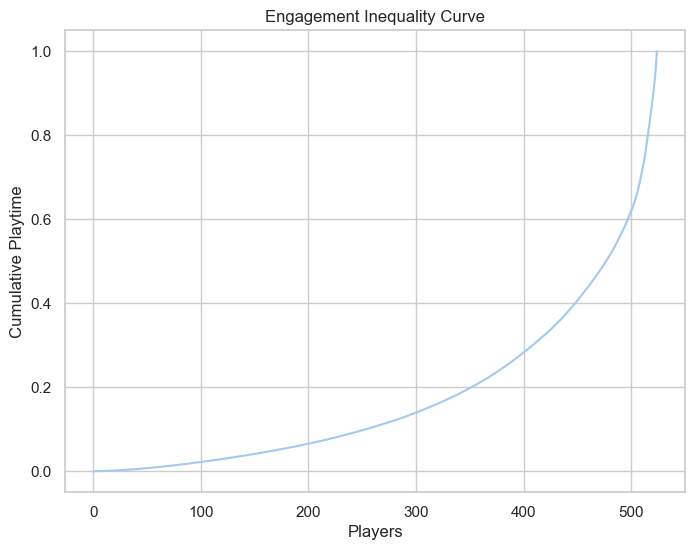

In [34]:
sorted_playtime = np.sort(df['avg_playtime_forever'])
cum_playtime = np.cumsum(sorted_playtime) / sum(sorted_playtime)

plt.figure(figsize=(8,6))
plt.plot(cum_playtime)

plt.title("Engagement Inequality Curve")
plt.xlabel("Players")
plt.ylabel("Cumulative Playtime")
plt.show()

## 15. Engagement Inequality Curve (Lorenz-style)
### 📊 Insight
The curve shows a highly uneven distribution of playtime, where a small proportion of games accounts for a large share of total engagement.

### 💼 Business Interpretation
This indicates that engagement is heavily concentrated in a few highly successful titles, while most games contribute minimally to total player activity. It highlights the importance of creating “hit” games that can capture and retain large audiences.

### 🔥 Strategic Insight
A small number of high-engagement games drive the majority of platform activity, meaning success depends on achieving strong retention rather than just launching many titles.

---

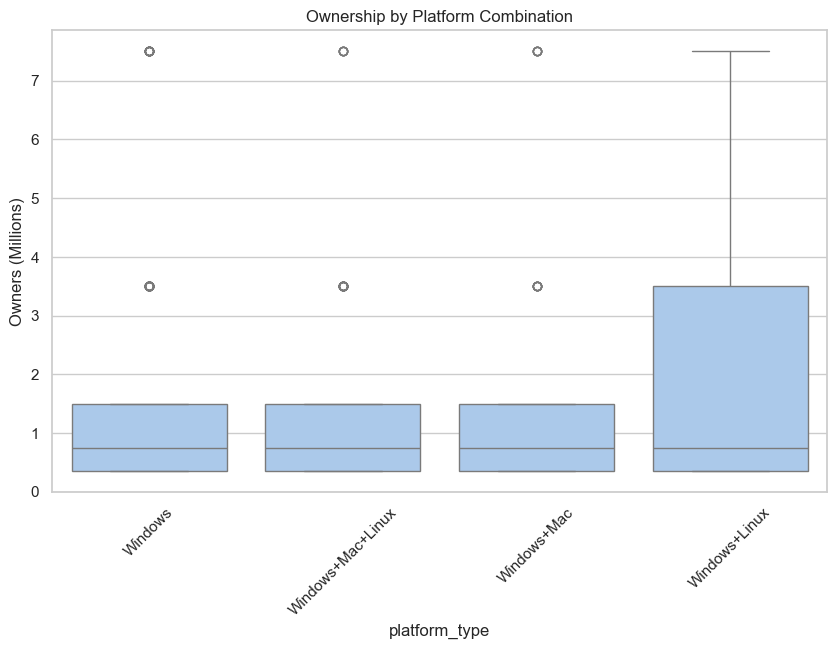

In [35]:
df_clean["platform_type"] = (
    df_clean["is_windows_supported"].map({1:"Windows", 0:""}) +
    df_clean["is_mac_supported"].map({1:"+Mac", 0:""}) +
    df_clean["is_linux_supported"].map({1:"+Linux", 0:""})
)

df_clean["platform_type"] = df_clean["platform_type"].str.lstrip("+")


plt.figure(figsize=(10,6))

sns.boxplot(
    x="platform_type",
    y=df_clean["owners_avg"] / 1e6,
    data=df_clean
)

plt.title("Ownership by Platform Combination")
plt.ylabel("Owners (Millions)")
plt.xticks(rotation=45)

plt.show()

## 16. Ownership by Platform Combination
### 📊 Insight

Multi-platform games (especially Windows + Linux) show higher variability and potential for higher ownership, while single-platform games (Windows only) tend to cluster at lower ownership levels.

### 💼 Business Interpretation

While expanding to multiple platforms increases potential reach, it does not guarantee success. Most games still fall into the low-to-mid ownership range, indicating that platform availability alone is not the primary growth driver.

### Strategic Insight

Platform expansion should be treated as a scaling strategy rather than a success driver. Developers should first focus on building strong gameplay and engagement, and then expand to additional platforms to maximize reach.

----

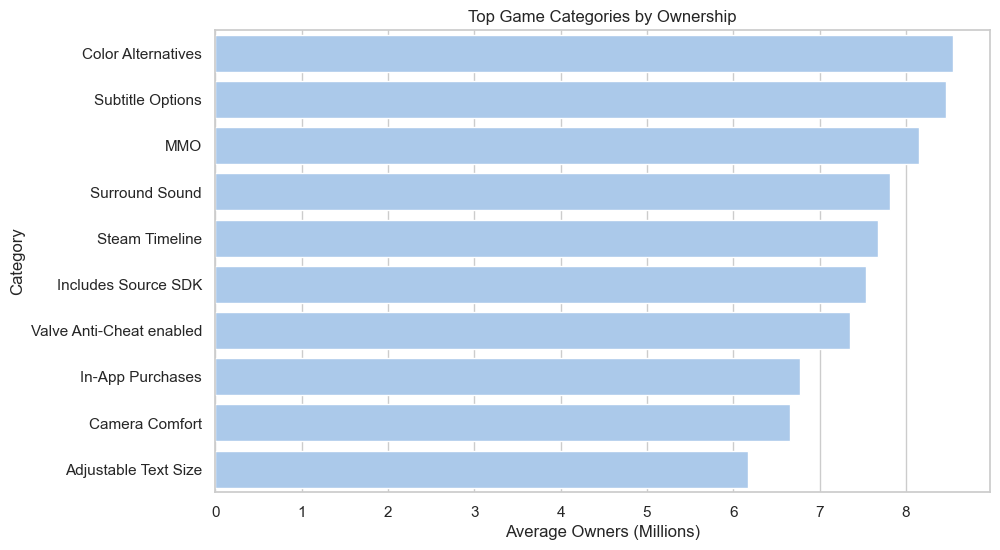

In [36]:
top_cat_perf = (
    df_cat.groupby("game_categories")["owners_avg"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cat_perf.values/1e6, y=top_cat_perf.index)

plt.title("Top Game Categories by Ownership")
plt.xlabel("Average Owners (Millions)")
plt.ylabel("Category")

plt.show()

## 📊 Top Game Categories by Ownership
### Insight

Non-core gameplay features such as Color Alternatives, Subtitles, and Accessibility options appear among the top categories with higher ownership, indicating that usability and inclusivity features are strongly associated with successful games.

### 💼 Business Interpretation

Games that focus on accessibility, user experience, and inclusivity tend to reach a wider audience, suggesting that these features are not just optional but contribute to higher adoption.

### Strategic Insight

Developers should prioritize accessibility and user-friendly features alongside gameplay to maximize reach and improve overall player acquisition.

---

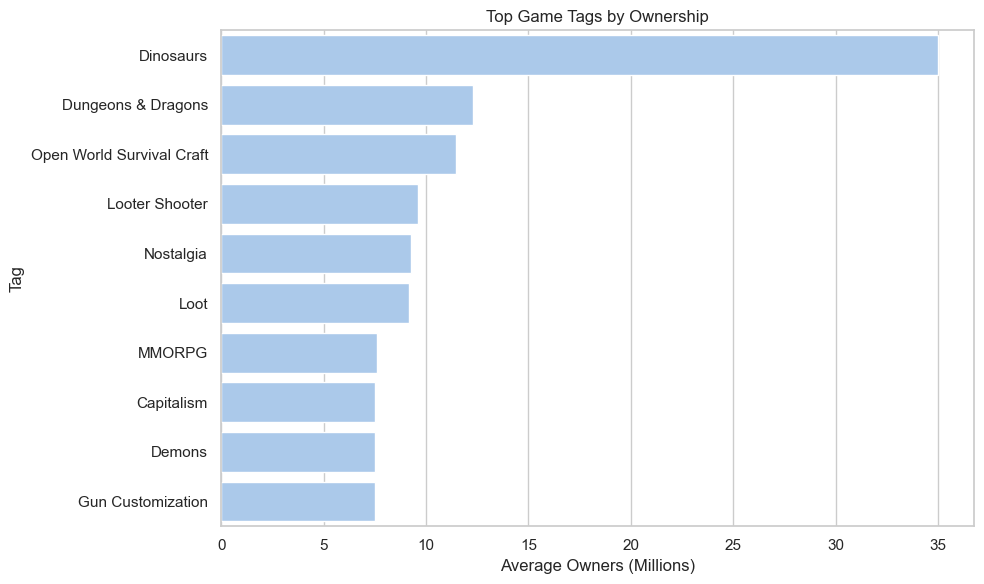

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_tag_perf.values / 1e6,
    y=top_tag_perf.index
)

plt.title("Top Game Tags by Ownership")
plt.xlabel("Average Owners (Millions)")
plt.ylabel("Tag")

plt.tight_layout()
plt.show()

## 📊 Top Game Tags by Ownership
### Insight

Niche and thematic tags such as Dinosaurs, Dungeons & Dragons, and Open World Survival Craft show significantly higher ownership, indicating strong player interest in specific immersive themes.

### 💼 Business Interpretation

Highly engaging and unique themes attract larger audiences, suggesting that differentiation through theme and concept plays a critical role in success.

### Strategic Insight

Focusing on strong, immersive, and trending themes can significantly boost game visibility and ownership, especially in a competitive market.

----

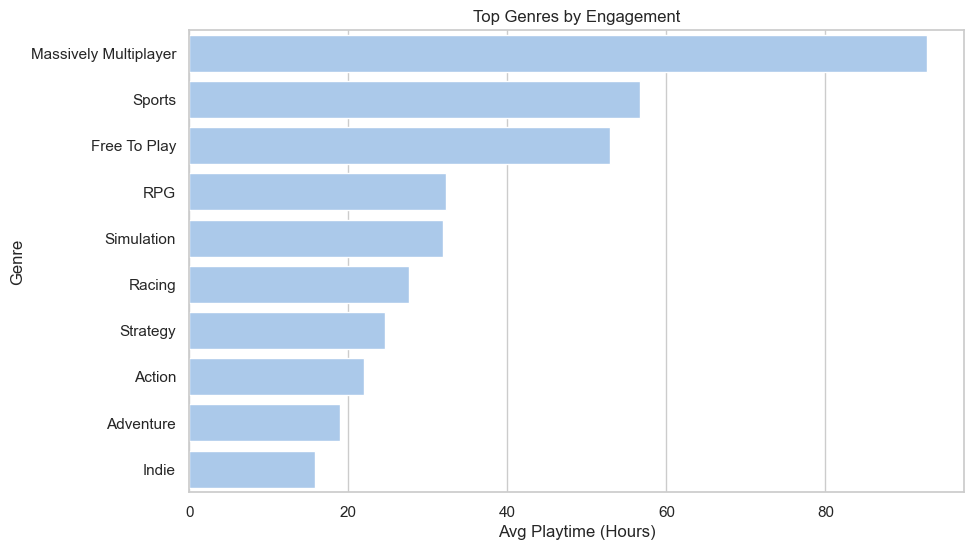

In [38]:
genre_engagement = (
    df_genre.groupby("game_genres")["avg_playtime_forever"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_engagement.values/60, y=genre_engagement.index)

plt.title("Top Genres by Engagement")
plt.xlabel("Avg Playtime (Hours)")
plt.ylabel("Genre")

plt.show()

## 📊 Top Categories by Engagement
### Insight
Certain genres such as RPG and Simulation show significantly higher engagement levels, indicating stronger player retention.

### 💼 Business Interpretation

High ownership genres are not always the most engaging, meaning acquisition and retention are driven by different genre dynamics.

### Strategic Insight

Developers should aim for genres that balance both high ownership and high engagement to ensure sustainable success.

-----

-------

## ⚠️ Limitations

- Ownership values represent estimated ranges rather than exact counts, which may introduce approximation bias
- Retention ratio is derived from playtime metrics and may not fully capture true user retention behavior
- Genre and tag classification relies on text parsing, which may introduce inconsistencies
- The dataset does not account for external factors such as marketing spend, brand strength, or seasonal trends

## 🚀 Future Improvements

- Develop a predictive model to estimate game success based on engagement and pricing features
- Perform segmentation analysis across developers and publishers to identify strategic patterns
- Conduct time-series forecasting to analyze market trends and release cycles
- Integrate external data sources such as live player counts, user reviews, and sentiment analysis

## 💼 Business Recommendations

- Prioritize improving player engagement through gameplay design and continuous content updates
- Leverage free-to-play or competitive pricing strategies to maximize initial user acquisition
- Invest in retention mechanisms such as progression systems, rewards, and live content updates
- Focus on high-performing genres to align with proven player demand
- Expand platform availability only after validating strong core game performance

-----

------

# ---------------------- FINAL STRATEGIC CONCLUSION ----------------------

## The analysis demonstrates that success in the gaming market is primarily driven by player engagement rather than pricing or review scores. Games with higher average playtime consistently achieve higher ownership, highlighting engagement as the strongest growth driver.

## Free-to-play models are effective for initial user acquisition, but long-term success depends on retaining players through engaging gameplay experiences. Additionally, the market exhibits a highly skewed distribution, where only a small number of games achieve large-scale success.

## As the number of game releases increases over time, average ownership per game remains inconsistent, indicating rising competition and market saturation.

## Overall, the industry follows a winner-takes-most dynamic. To succeed, developers must focus on retention, accessibility, and differentiated gameplay experiences rather than relying solely on pricing or ratings.